In [1]:
import os
import json
from datetime import datetime
import numpy as np


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec
import seaborn_image as isns

from scipy.constants import Boltzmann as kb
#from hdr.oop_diffusion import *
#from hdr.utils import *
#from hdr.analytical_solution import *

import warnings

/Users/korsk/Documents/Github/ConfinedDiffusion/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
from scipy.linalg import inv
#matplotlib.use('Qt5Agg')

from scipy.optimize import curve_fit

def savefig(name):
   plt.savefig(os.path.join(OUTDIR, f"{name}.pdf"))
   plt.close()
import os
OUTDIR = "mj_line_diffusion_apr3_plots"
os.makedirs(OUTDIR, exist_ok=True)

#  --------------------------------------------------------------------------------
# MAIN CLASS
#  --------------------------------------------------------------------------------

import numpy as np
from tqdm import tqdm


class LineRandomWalk():
    def __init__ (self, 
                  N,
                  dt,
                  steps,
                  D,
                  H):
        
        # Simulation parameters
        self.N      = N         # Number of particles (simultaneous runs)
        self.H      = H         # line length
        self.D      = D         # Diffusion coefficient  [m/s^2]
        self.dt     = dt        # Time step              [s]
        self.steps  = steps     # Number of time steps   

        self.sigma = 2 * self.D * self.dt

        self.InitializeSimulation()

    def InitializeSimulation(self):
        # Initialize particle positions (z)
        self.z = np.ones(self.N) * self.H/2  #np.random.uniform(0, self.H, self.N)

        # current position and trajectory container
        self.currPos = np.array([self.z])  # shape: (1, N)
        self.TRAJ = [self.currPos.copy()]  # store each timestep's positions

    def SingleStep(self):
        """
        Perform a single diffusion step for all particles.
        """
        # sample step sizes from a distribution 
        dz = np.sqrt(self.sigma) * np.random.randn(self.N)

        # Update positions
        self.currPos[0] += dz

        # Reflective boundaries at z = 0 and z = H
        below_zero = self.currPos[0] < 0
        above_H    = self.currPos[0] > self.H

        self.currPos[0][below_zero] = -self.currPos[0][below_zero]
        self.currPos[0][above_H]    = 2*self.H - self.currPos[0][above_H]

        # Save positions at this time step
        self.TRAJ.append(self.currPos.copy())

    def runSimulation(self):
        """
        Run the full simulation for 'steps' time steps.
        """
        for _ in tqdm(range(self.steps)):
            self.SingleStep()
    
    def getMeanSquaredDisplacement(self):
        """
        Computes MSD for each particle separately, returning a matrix of shape (steps+1, N).
        """
        # Convert list of arrays to one NumPy array of shape (steps+1, 3, N)
        traj_array = np.array(self.TRAJ)  # Shape: (steps+1, 3, N)

        # Reference initial positions for all particles
        x0 = traj_array[0, 0, :]

        # Compute squared displacement at each time step for each particle
        msd_matrix = (traj_array[:, 0, :] - x0)**2

        # Store as an attribute for later use
        self.MSD = msd_matrix  # Shape: (steps+1, N)

    def plotTrajectory(self, fig,ax, particle_index=0):
        """
        Plot the 3D trajectory for a single particle.
        By default, plots the first particle (index 0).
        """
        # Convert list of arrays to one NumPy array of shape (steps+1, 3, N)
        traj_array = np.array(self.TRAJ)

        # Extract x, y, z for the chosen particle
        z_vals = traj_array[:, 0, particle_index]

        # Plot the trajectory
        ax.plot(z_vals, label=f'Particle {particle_index}')

    def plotMSD(self, fig, ax, particle_index=0):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, self.MSD[:, particle_index], alpha=0.3, label=f"Particle {particle_index}") 

        ax.set_title("MSD for Individual Particles")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()

    def plotMeanMSD(self, fig, ax):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, np.mean(self.MSD, axis=1), alpha=0.3, label="Mean MSD") 

        ax.set_title("Ensemble MSD")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()


In [71]:
# ------------------------------------------------------------------------------------
# Retain each run in a safe place.
# ------------------------------------------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"MJ_FREE_DIFFUSION_MAR28/run_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------------------------------


N = 1000                                # number of simultaneous simulations
dt = 1/10000                              # 1/fps
steps = 1000                            # steps
total_time = steps * dt
r = 50e-9                               # nm         
T   = 22 + 273.15                       # K                 
D = kb * T / (6 * np.pi * 0.001 * r)    # m^2/s
box_length_m = 225e-9                   # m?

# Can also calculate D from Stokes Einstein for Experimental Comparison
#T   = 22 + 273.15                       # K
#R_h = 50//2 * 10**(-9)                  # m
#D = kb * T / (6 * np.pi * 0.001 * R_h)  # m^2/s

print(f"Simulation Settings: \n >Particles {N} \n >Diffusion {D:.2e} \n >Box Length {box_length_m:.2e} \n > total time {total_time:.2e} [s]")

Simulation Settings: 
 >Particles 1000 
 >Diffusion 4.32e-12 
 >Box Length 2.25e-07 
 > total time 1.00e-01 [s]


In [72]:
# Save parameters
params = {
    "N": N,
    "dt": dt,
    "steps": steps,
    "D": D
}

with open(os.path.join(output_dir, "params.json"), 'w') as f:
    json.dump(params, f, indent=4)

# ------------------------------------------------------------------------------------
# Run Simulation
# ------------------------------------------------------------------------------------
sims = {}
line_sim = LineRandomWalk(N, dt, steps, D, H = box_length_m)
line_sim.runSimulation()
line_sim.getMeanSquaredDisplacement() # This is good :)
#free_sim.getMeanSquaredDisplacementFFT() # this is SHIT
time_arr = np.linspace(0, dt * steps, steps)
sims['confined'] = (line_sim, time_arr)


100%|██████████| 1000/1000 [00:00<00:00, 31493.73it/s]


Text(0, 0.5, 'time [s]')

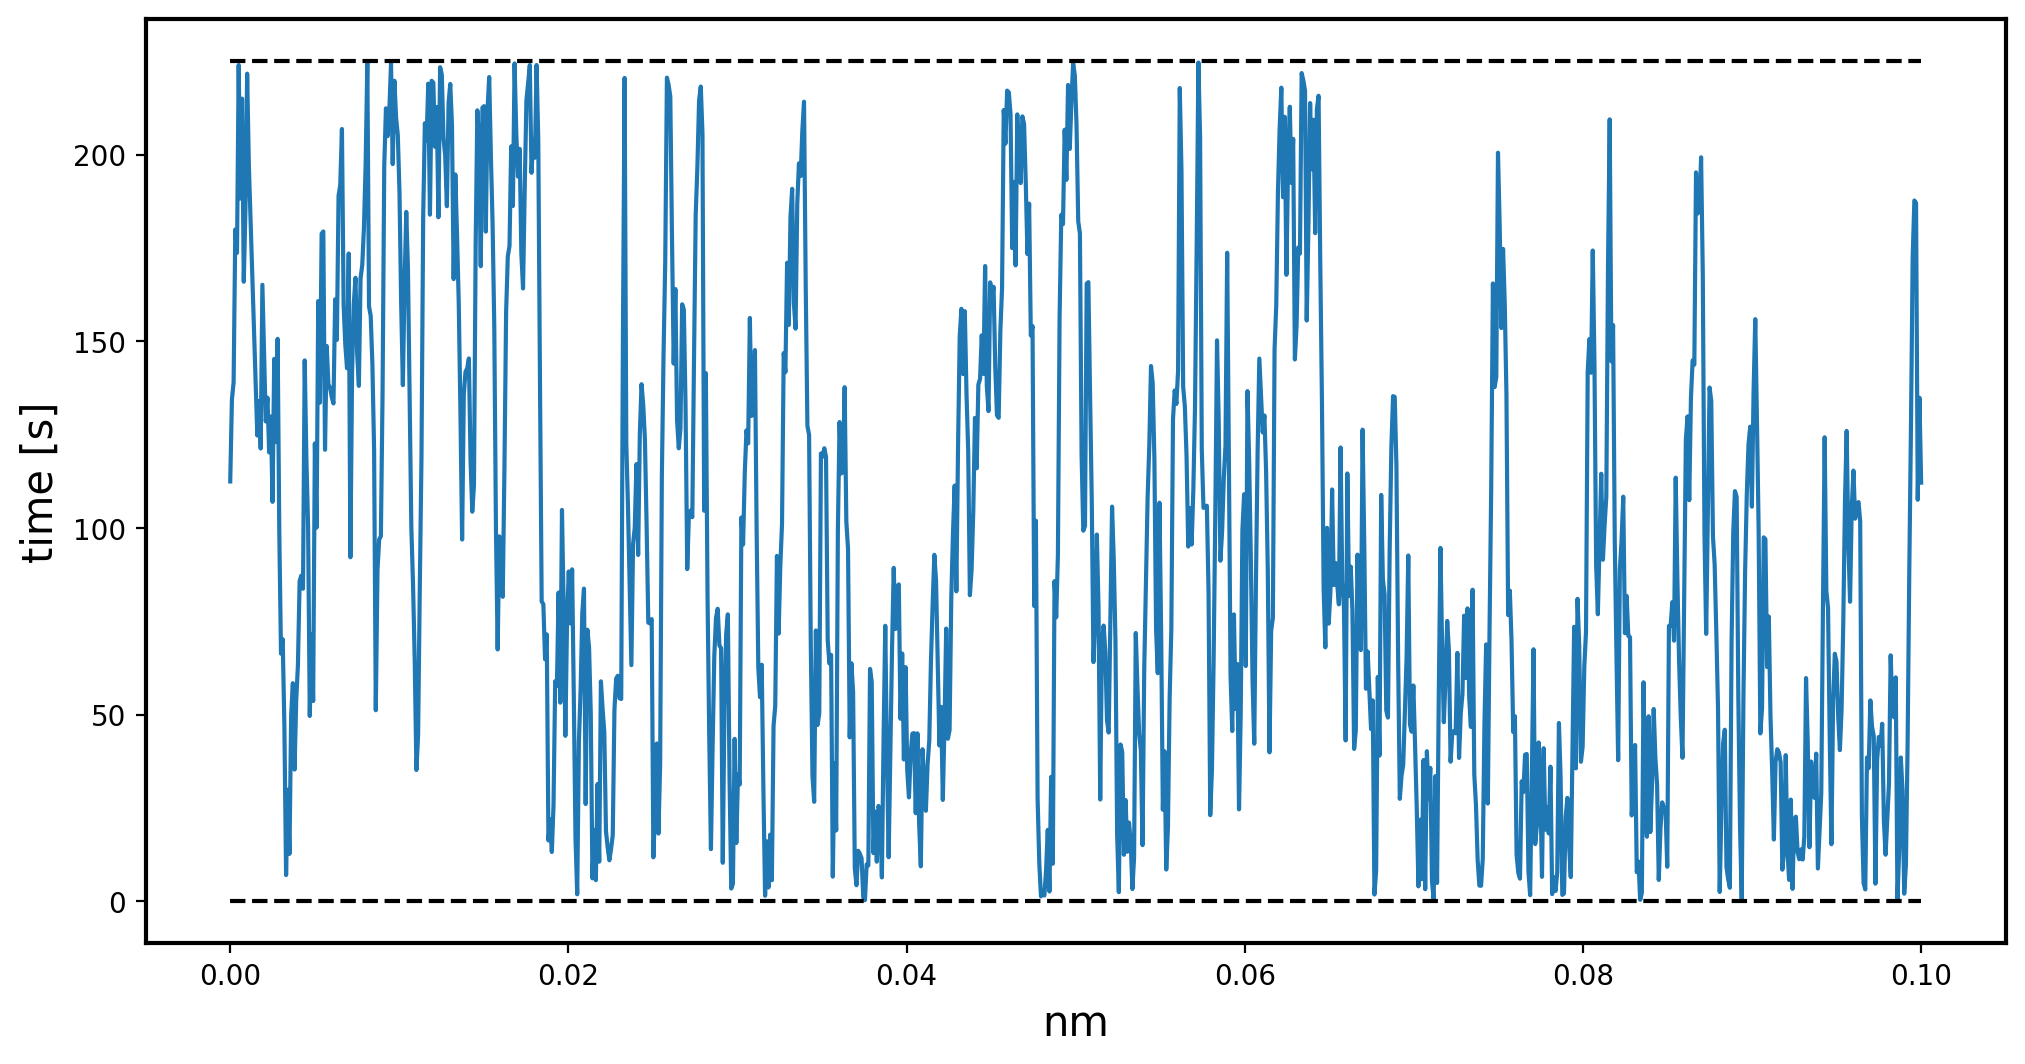

In [73]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

# fig1 = plt.figure(dpi=200, figsize=(12,6))
# ----------------------------------------
# AXIS 1
# ----------------------------------------

#free_sim.plotTrajectory(fig1, ax1, particle_index=1)
#free_sim.plotTrajectory(fig1, ax1, particle_index=0)
XD = np.array(line_sim.TRAJ)# what are these untis?
x = np.array(XD[:1000, 0, 0]) * 10**9

fig = plt.figure(dpi=200, figsize=(12,6))
ax1 = fig.add_subplot(111)

# Main trajectory
ax1.plot(time_arr, x)
ax1.hlines(225, 0, steps*dt , color='black', linestyles='dashed')
ax1.hlines(0, 0, steps*dt, color='black', linestyles='dashed')

ax1.set_xlabel('nm')
ax1.set_ylabel('time [s]')
# ----------------------------------------
# AXIS 2
# ----------------------------------------

# ax2 = fig.add_subplot(122)
# #ax2.set_aspect('auto')
# ax2.set_aspect(0.03)


# # plot theoretical displacement histogram
# def distFunc(t, D):
#     return np.sqrt(6 * D * t)
# lag = np.arange(0, 100, 1) 
# pos_dist = distFunc(dt * lag, D) * 10**6

# ax2.plot(dt * lag, pos_dist, 'r' , label=r'MSD = $\sqrt{2D\Delta t}$')
# ax2.plot(dt * lag, -pos_dist, 'r')
# ax2.grid(alpha=0.2)
# for i in tqdm(range(100)):
#         x1 = np.array(XD[:100, 0, i]) * 10**6
#         y1 = np.array(XD[:100, 1, i]) * 10**6
#         z1 = np.array(XD[:100, 2, i]) * 10**6
#         #free_sim.plotFlattenedTrajectory(fig, ax2, particle_index=i, x_max=100)
#         abs_pos = np.sqrt(x1**2 + y1**2 + z1**2) - np.sqrt(x1[0]**2 + y1[0]**2 + z1[0]**2)
#         #print(np.shape(abs_pos))
#         # Plot the trajectory
#         ax2.plot(dt * lag, abs_pos, color='black', linestyle='dashed', alpha=0.5, linewidth=1)
#         ax2.plot(0, abs_pos[0], 'ro', markersize=1)
# ax2.legend()
# ax2.set_ylabel(r'$\sqrt{x^2 + y^2 + z^2}$ $[\mu m]$')
# ax2.set_xlabel(r'$Time [s]$')

# ax1.text2D(0.1, 0.85, "A", transform=ax1.transAxes,
#            fontsize=25)

# ax2.text(-0.1, 0.99, "B", transform=ax2.transAxes,
#            fontsize=25)
# y_fig = 0.85  # adjust this to match the height of your A/B labels

# line = plt.Line2D([0.05, 0.95], [y_fig, y_fig],
#                   transform=fig.transFigure,
#                   color='black',
#                   linestyle='-',
#                   linewidth=1,
#                   alpha=0.7)
# #fig.add_artist(line)
# plt.tight_layout()
# #savefig('free_diff_visual')


In [6]:
# implementation of FGLS (Feasible Generalized Least-Squares)
#data
free_MSD = free_sim.MSD
F, N_particles = free_MSD.shape
x = free_MSD[:,0]
x = np.reshape(x, (F, 1))


In [7]:
def getDiffusionFGLS(msd, dt, ndim, D_0, sigma2_0):
    max_iter = 100
    tol = 1e-22
    F, N_particles = msd.shape

    beta = np.array(([[D_0], [sigma2_0]]))
    A = np.column_stack((
        2 * dt * np.arange(1, F+1),
        2 * np.ones(F)
    ))
    def build_sigma(D, sigma2, F, dt):
        """
        Build MSD covariance matrix using Vestergaard 2007 formula.
        
        D       : diffusion coefficient
        sigma2  : localization error variance
        F       : number of lag times (MSD points)
        dt      : frame interval
        N_particles: number of steps in trajectory (for normalization)
        
        returns: Sigma (F x F)
        """
        Sigma = np.zeros((F, F))
        x = sigma2/(D * dt)
        
        for i in range(F):
            for j in range(F):
                #min_ij = min(i+1, j+1)  # +1 because Python is 0-indexed
                #max_ij = max(i+1, j+1)
                #factor = 1.0 / (N_particles - max_ij + 1)
                
                Sigma[i, j] =  2 * D * dt * ((1 + 2*x)if i == j else 0 -x/2 if i + 1 == j else -x/2 if i == j + 1 else 0)
                #Sigma[i, j] =   ((1) if i == j else 0)#-x/2 if i + 1 == j else -x/2 if i == j + 1 else 0)
        return Sigma

    # sigma = build_sigma(D, 1, F, 1, N_particles=F)

    for k in tqdm(range(max_iter)):
        # get old
        D_old = beta[0, 0]
        sigma2_old = beta[1, 0]
        
        # build covariance matrix - eqn 3 in Xavier 2012
        sigma = build_sigma(D_old, sigma2_old, F, dt)
        sigma_inv = np.linalg.inv(sigma)
        # calculate new beta
        beta_new = np.linalg.inv(A.T @ sigma_inv @ A) @ (A.T @ sigma_inv @ msd)
        
        # convergence
        if np.linalg.norm(beta_new - beta) < tol:
            print(f"Converged in {k} iterations")
            beta_cor = beta / ndim
            return beta_cor

        beta = beta_new

    # adjust this?
    beta_cor = beta / ndim
    return  beta_cor

free_MSD = free_sim.MSD
F, N_particles = free_MSD.shape
x = free_MSD[:,0]
x = np.reshape(x, (F, 1))
print(x[:50].shape)
(D_FGLS, sigma2_FGLS) = getDiffusionFGLS(x[:5], dt, 3, 1e-12, 1e-12)

print('FGLS Radius', (kb * T)/(6 * np.pi * 10**(-3) * (D_FGLS)) * 10**9)

(50, 1)


  4%|▍         | 4/100 [00:00<00:00, 12995.52it/s]

Converged in 4 iterations
FGLS Radius [51.31278203]


In [8]:
def linear(x, a, b):
    return a * x + b

def getDiffusionOLS(msd, lag, pixel_size, exposure_time, max_time=3):
    time_s = exposure_time * lag
    msd_m2 = msd * pixel_size**2

    # MSD diffusion
    from scipy.optimize import curve_fit
    popt, cov = curve_fit(linear, time_s[:max_time], msd_m2[:max_time]) # m^2/s
    D = popt[0]
    alpha = popt[1]

    return (D/(2 * 3), alpha)

free_MSD   = free_sim.MSD
lag = np.arange(0, len(free_MSD[:,0]), 1)
print(free_MSD[:,0].shape)

(D_OLS, alpha) = getDiffusionOLS(free_MSD[:,0], lag, 1, dt, 5)
print((kb * T)/(6 * np.pi * 10**(-3) * D) * 10**9)

(1001,)
50.0


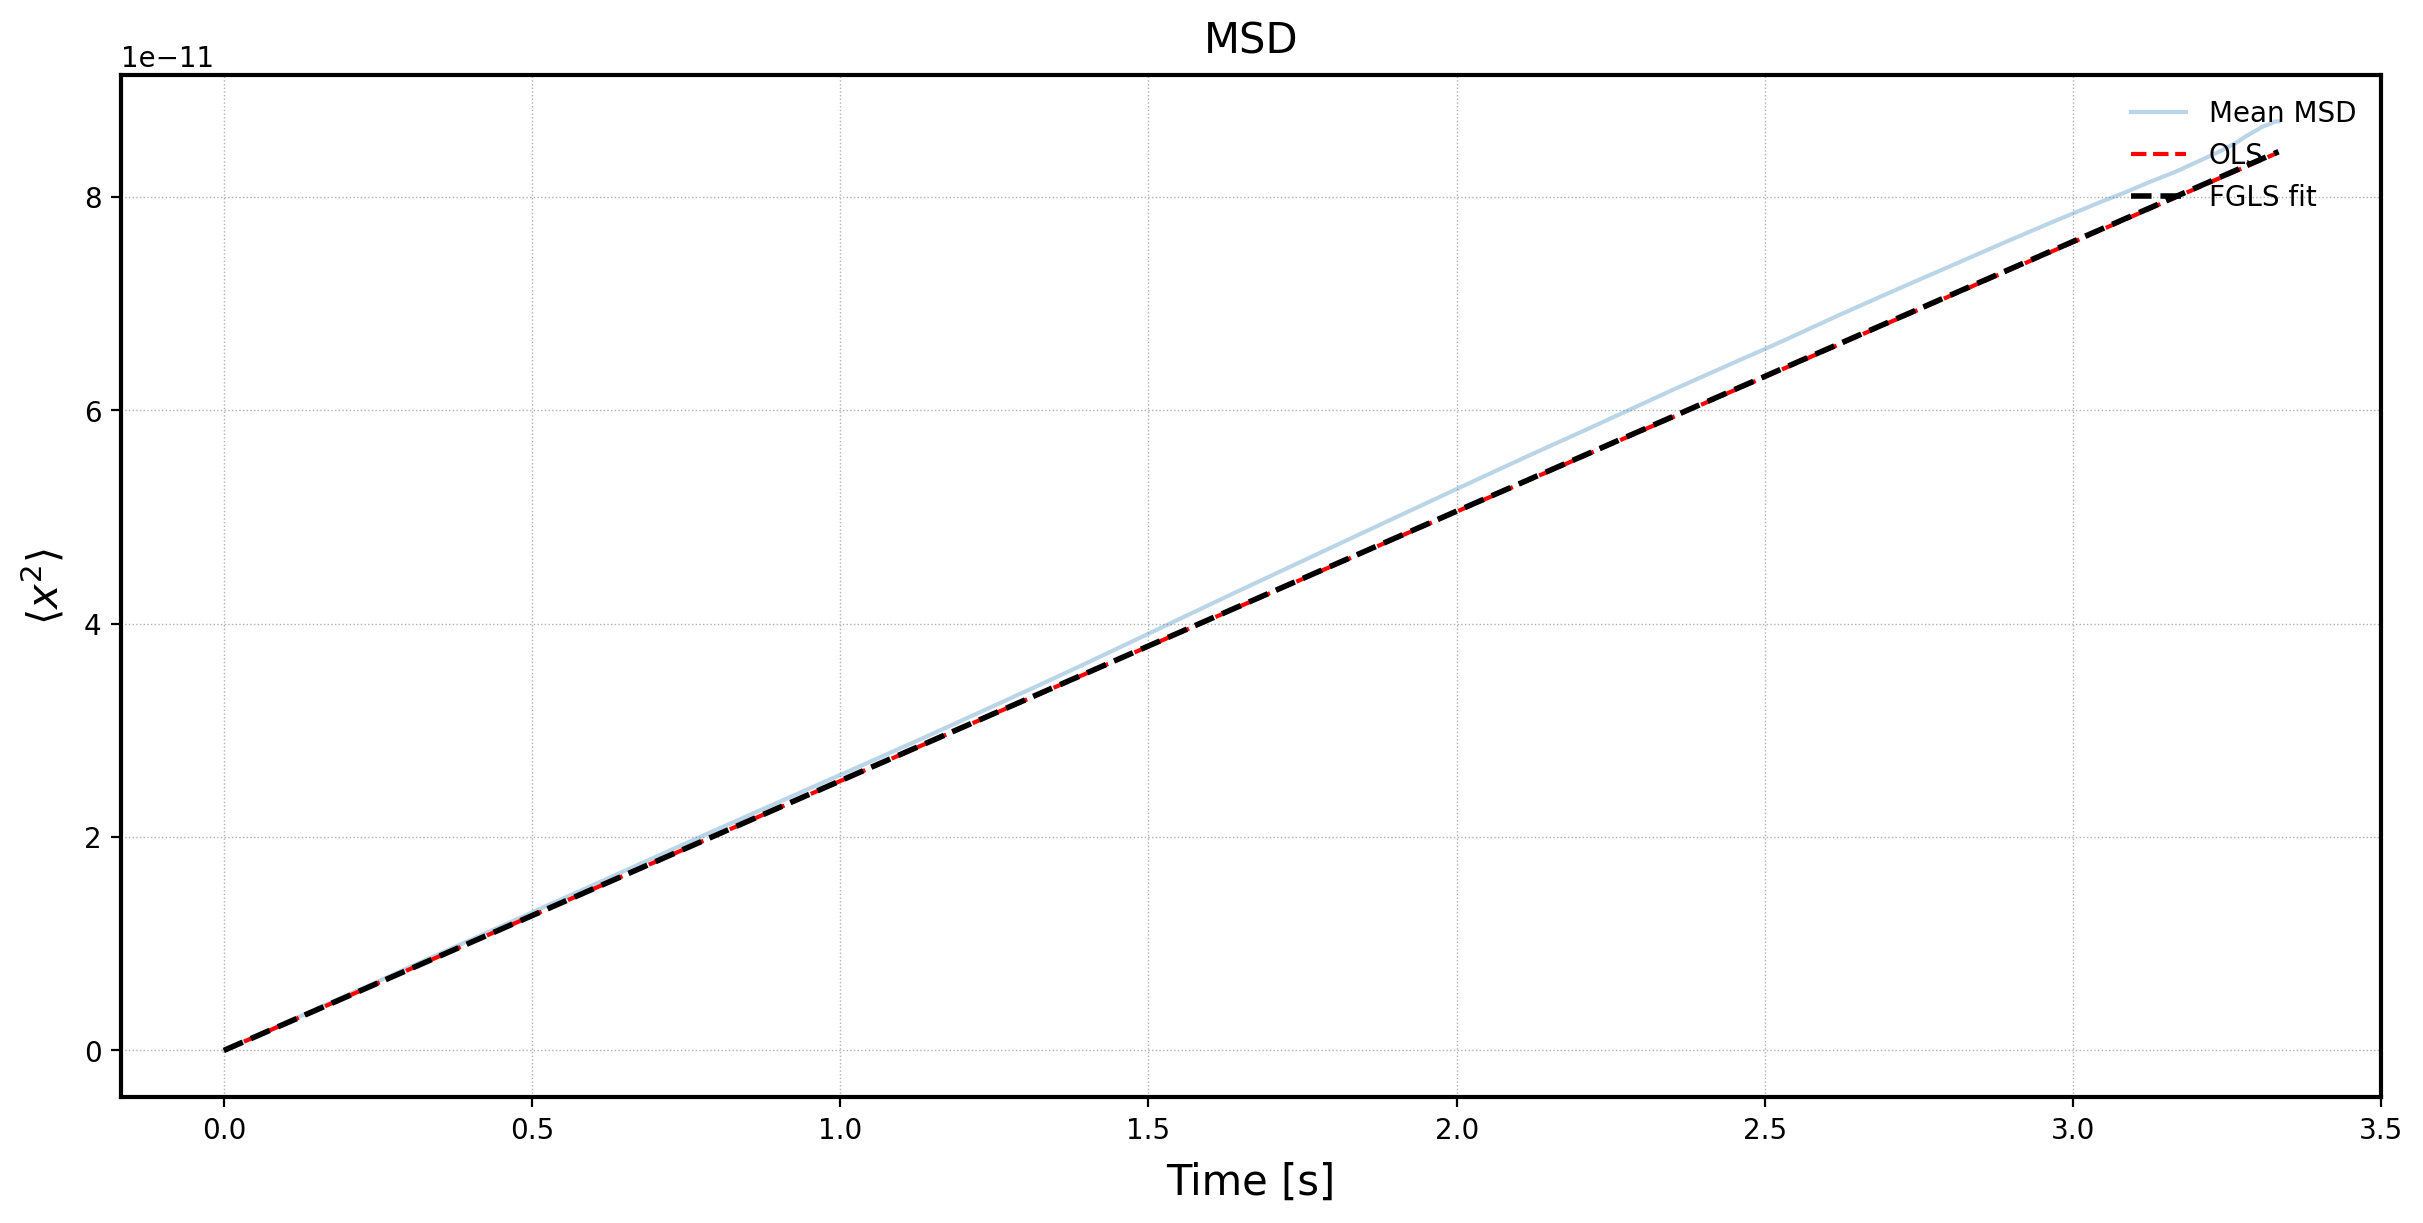

In [9]:
%matplotlib inline
fig4 = plt.figure(figsize=(12,6), dpi=200, constrained_layout=True)
ax1 = fig4.add_subplot(111)

# plot Mean ensemble MSD
free_sim.plotMeanMSD(fig4, ax1)
# True Analytical Curve
time_arr = np.linspace(0, free_sim.dt * free_sim.steps, free_sim.MSD.shape[0])
#ax1.plot(time_arr, free_MSD[:,0])

OLS_LINE = 6 * D_OLS * time_arr
GLS_LINE = 6 *  D_FGLS * time_arr
# plotting
ax1.plot(time_arr, OLS_LINE, 'r--', label='OLS')

# ----- Plot data and fit -----
time = time_arr
#ax1.plot(time_arr, x, 'o', label='Trajectory MSD')
ax1.plot(time_arr, GLS_LINE, 'k--', lw=2, label='FGLS fit')


ax1.set_title("MSD", pad=8)
ax1.set_xlabel("Time [s]", labelpad=6)
ax1.set_ylabel(r"$\langle x^2 \rangle$", labelpad=6)
ax1.grid(True, which='both', linestyle=':', linewidth=0.5)
ax1.legend(loc='upper right', frameon=False)

In [ ]:
F, N = free_MSD.shape

R_OLS_arr = []
R_GLS_arr = []
for p in tqdm(range(N)):
    msd = free_MSD[:, p]
    # prep the array
    F = len(msd)
    x_OLS = np.reshape(msd, (F, ))
    x_GLS = np.reshape(msd, (F, 1))
    print(x_GLS.shape)
    
    # OLS
    lag = np.arange(0, len(msd), 1)
    (D_OLS, sigma2_OLS) = getDiffusionOLS(x_OLS, lag, 1, dt, 5)
    print((kb * T)/(6 * np.pi * 10**(-3) * (D_OLS)) * 10**9)

    # FGLS
    (D_FGLS, sigma2_FGLS) = getDiffusionFGLS(x_GLS[:15], dt, 3, 1e-11, 1e-11)
    print(((kb * T)/(6 * np.pi * 10**(-3) * (D_FGLS)) * 10**9))

    R_OLS_arr.append((kb * T)/(6 * np.pi * 10**(-3) * (D_OLS)) * 10**9)
    R_GLS_arr.append((kb * T)/(6 * np.pi * 10**(-3) * (D_FGLS)) * 10**9)

    
#print('FGLS Radius', (kb * T)/(6 * np.pi * 10**(-3) * (D_FGLS)) * 10**9)


In [12]:
print(np.shape(R_OLS_arr))

(1000,)


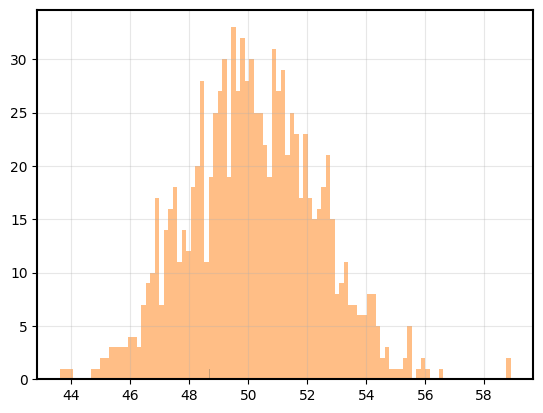

In [19]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

ax1.hist(R_GLS_arr[0], alpha=0.5, label='Optimal GLS', bins=100)
ax1.hist(R_OLS_arr, alpha=0.5, label='OLS, 5 pts' , bins=100 )
ax1.grid(alpha=0.3)
